In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# # find any gaps in date greater than 1 hour
# def find_gaps(dataframe, date_column):
#     dataframe = dataframe.sort_values(by=date_column)
#     dataframe[date_column] = pd.to_datetime(dataframe[date_column])
#     dataframe['next_date'] = dataframe[date_column].shift(periods=-1)
#     dataframe['gap'] = (dataframe['next_date'] - dataframe[date_column]).dt.total_seconds() / 3600  # Convert gap to hours
#     gaps = dataframe.loc[dataframe['gap'] == 1]  # Compare only with the next row
#     gaps = gaps.rename(columns={date_column: 'start_date', 'next_date': 'end_date'})
#     return gaps.loc[gaps['gap'] > 1,['start_date', 'end_date', 'gap']]


# # find any null values in pm25


# df = pd.read_csv('PM10&PM2.5.csv', header=1)
# gaps_df = find_gaps(df, 'Date')
# print(gaps_df)

# # null_values_df = df.loc[df['pm25'].isnull()]
# # print(null_values_df)

2025-07-13 23


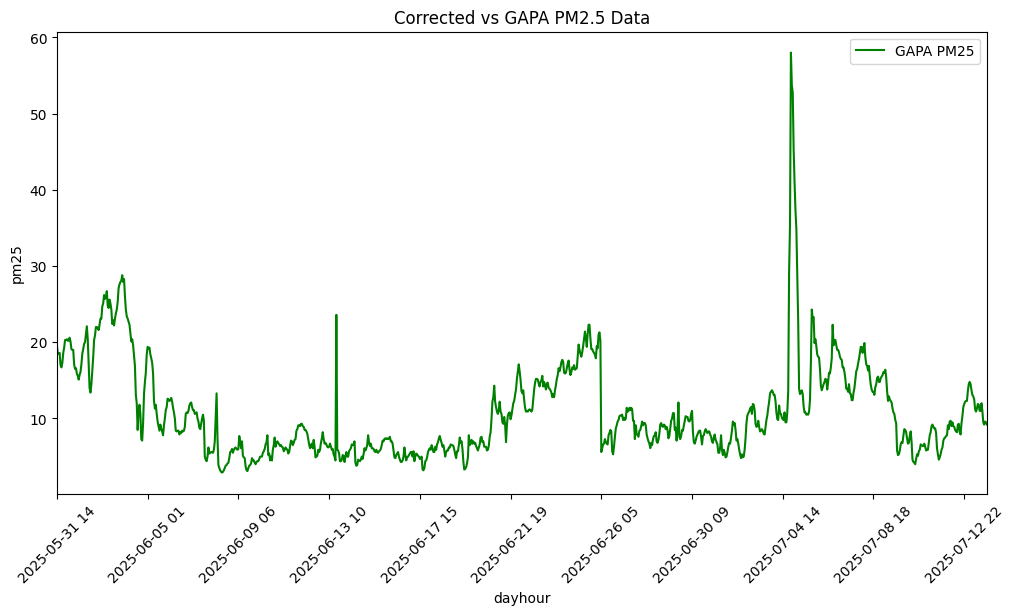

In [15]:
def preprocess_GAPA(file_path):
    gapa = pd.read_csv(file_path, header=2)
    gapa.columns = ['Date', 'PMHR_2', 'PMHR', 'PMHR25', '24H_PMHR25', 'PMHRC', 'pm25']
    gapa = gapa[['Date', 'PMHR']]
    # return gapa

    gapa['time'] = pd.to_datetime(gapa['Date'], format='%d-%b-%Y %H:%M')
    gapa['day'] = gapa['time'].dt.strftime("%Y-%m-%d")
    gapa['day'] = pd.to_datetime(gapa['day']).dt.date
    gapa['dayhour'] = gapa['time'].dt.strftime("%Y-%m-%d %H")
    gapa = gapa[['day','dayhour','PMHR']]
    gapa.rename(columns={'PMHR':'rpm25'}, inplace=True)
    gapa.dropna(subset=['rpm25'], inplace=True)

    h_gapa = gapa.groupby('dayhour').agg(
        pm25=('rpm25', lambda x: x.mean(skipna=True)),
    ).reset_index()

    h_gapa = h_gapa.sort_values('dayhour')
    print(h_gapa['dayhour'].max())

    return h_gapa[['dayhour', 'pm25']]

gapa = preprocess_GAPA('PM10&PM2.5.csv')
plt.figure(figsize=(12, 6))
plt.plot(gapa['dayhour'], gapa['pm25'], label='GAPA PM25', color='green')
plt.title('Multiple Lines on a Single Plot')
plt.xlabel('dayhour')
plt.ylabel('pm25')
plt.xticks(gapa['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(gapa['dayhour'].min(), gapa['dayhour'].max())
plt.legend()
plt.title("Corrected vs GAPA PM2.5 Data")
plt.show() # plot with no raw data
plt.show()


# gapa = pd.read_csv('PM10&PM2.5.csv', header=2)
# gapa.columns = ['Date', 'PMHR_2', 'PMHR', 'PMHR10', '24H_PMHR10', 'PMHRC', 'pm25']
# gapa = gapa[['Date', 'PMHR']]

# to_csv = gapa.to_csv('fixed_PM10&PM2.5.csv', index=False)

# plt.figure(figsize=(12, 6))
# plt.plot(gapa['Date'], gapa['PMHR'], marker='o', linestyle='-')
# plt.xticks(gapa['Date'][::100], rotation=45) # Show every 100th tick
# plt.show()
